(np.float64(0.9686274509803922), np.float64(0.9882352941176471), np.float64(0.9607843137254902), np.float64(1.0))
(np.float64(0.7511726259131103), np.float64(0.9014225297962322), np.float64(0.7244905805459438), np.float64(1.0))


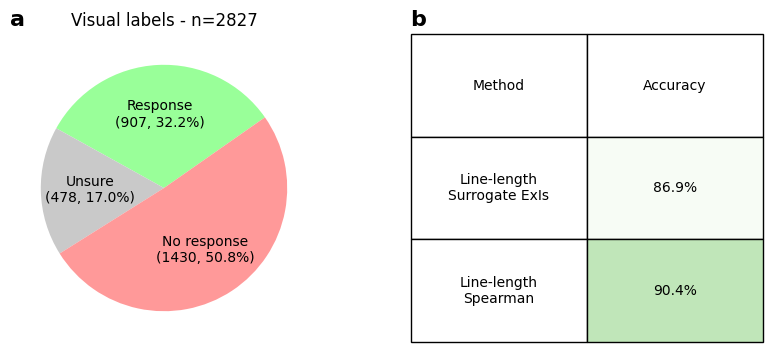

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2
%aimport connectivity

from connectivity.enums import ResponseLabel

base_path = "D:/data"
patient_id = "EL027"
SOURCE = "output" # "publish_data/paper"
CLEAN_DATA_FILE = "out/clean/bad_responses_dict.json"
RESPONSES_FILE = f"../{SOURCE}/significant_responses/response_channels_lf_cfm_3.json" #_cfm_2.json"
LABEL_COL = "label" #"CFM_label"
EXTENDED_MEASURES_FILE = f"../{SOURCE}/significant_responses/extended_measures_lf.json"
n_replications = 12

df = pd.read_json(RESPONSES_FILE)
extended_df = pd.read_json(EXTENDED_MEASURES_FILE)

df = df.merge(
    extended_df,
    on=["patient_id", "stim_channel_name", "response_channel_name"],
    how="left"
) # ["EL011", "EL013", "EL014", "EL020"]#
allowed_ids = ["EL019", "EL020", "EL021", "EL022", "EL026", "EL027", "EL028", "EL011", "EL013", "EL014", "EL015", "EL016"]
df = df[df["patient_id"].isin(allowed_ids)]


methods = ["surrogate_p_value_fdr_corrected", "spearman_p_value_fdr_corrected"] #"n1_spearman_p_value_fdr_corrected", "n2_spearman_p_value_fdr_corrected", "peak_to_peak_spearman_p_value_fdr_corrected", "root_mean_square_spearman_p_value_fdr_corrected"] 
percentiles = [0.005, 0.005, 0.005, 0.005, 0.005, 0.005]
results = []

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

mask_response = (df[LABEL_COL] == ResponseLabel.RESPONSE.value) | (df[LABEL_COL] == ResponseLabel.RESPONSE_DECREASING.value)
mask_unsure = (df[LABEL_COL] == ResponseLabel.UNSURE.value) | (df[LABEL_COL] == ResponseLabel.NO_LABEL.value)
mask_no_response = (df[LABEL_COL] == ResponseLabel.NO.value) | (df[LABEL_COL] == ResponseLabel.DRIFT.value)

values = [len(df[mask_response]), len(df[mask_unsure]), len(df[mask_no_response])]
labels = [f"Response", f"Unsure", f"No response"]
colors = ["#99FF99", "#c9c9c9", "#FF9999"]

def pie_fmt(pct):
    total = sum(values)
    val = int(round(pct * total / 100))
    name = labels[pie_fmt.i]
    pie_fmt.i += 1
    return f"{name}\n({val}, {pct:.1f}%)"

# ax1.pie(
#     values,
#     labels=[f"Response ({values[0]})", f"Unsure ({values[1]})", f"No response ({values[2]})"],
#     colors=colors,
#     autopct="%1.2f%%",
#     startangle=35,
# )
pie_fmt.i = 0
ax1.pie(
    values,
    labels=None,
    colors=colors,
    autopct=pie_fmt,
    startangle=35,
    pctdistance=0.6,
)

   

ax1.set_title(f"Visual labels - n={len(df)}")

friendly_method_name = ["Line-length\nSurrogate ExIs", "Line-length\nSpearman", "N1 Spearman", "N2 Spearman", "PP Spearman", "RMS Spearman"]

for percentile, method in zip(percentiles, methods):
    true_positives = len(df[mask_response & (df[method] < percentile)])
    false_positives = len(df[mask_no_response & (df[method] < percentile)])
    true_negatives = len(df[mask_no_response & (df[method] >= percentile)])
    false_negatives = len(df[mask_response & (df[method] >= percentile)])
    
    total_pop = df[mask_response | mask_no_response]

    results.append({
        "Method": method,
        "TP": true_positives,
        "FP": false_positives,
        "TN": true_negatives,
        "FN": false_negatives,
        "Accuracy": (true_negatives + true_positives) / len(total_pop)
    })


summary_df = pd.DataFrame(results)

cols_headers = ["Method", "Accuracy"]
summary_df = summary_df[cols_headers].values

formatted_matrix = [
    [
        (f"{value:.1%}" if j == 1 else friendly_method_name[i])
        for j, value in enumerate(row)
    ]
    for i, row in enumerate(summary_df)
]
table = ax2.table(
    cellText=formatted_matrix,  # Content
    colLabels=
       cols_headers 
    ,  # Column headers
    loc="center",
    cellLoc="center",
    bbox=[0, 0, 1, 1]  # [left, bottom, width, height] 
)
table.scale(0.5, 0.5)
table.auto_set_font_size(False)
table.set_fontsize(10)
cmap = plt.cm.Greens
min_color_val = np.nanmin(summary_df[:, 1:])
max_color_val = np.nanmax(summary_df[:, 1:]) * 1.1
# Apply colors based on value
for i in range(summary_df.shape[0]):
    for j in range(summary_df.shape[1]):
        if j > 0:
            value = summary_df[i, j]
            color = cmap((value-min_color_val)/(max_color_val-min_color_val))  # Get color from colormap
            table[i+1, j].set_facecolor(
                color
            )  # +1 because row headers exist
            print(color)
m
table.auto_set_column_width(
    col=2
)

ax2.axis('off')


ax1.set_title("a", loc='left', fontsize=16, fontweight='bold')
ax2.set_title("b", loc='left', fontsize=16, fontweight='bold')

plt.savefig("../output/figures/sfigure5.pdf", bbox_inches='tight', dpi=300)
plt.savefig("../output/figures/sfigure5.svg", bbox_inches='tight', dpi=300)
plt.show()